# SPRINT 9
## ANÁLISIS DE MARKETING PARA SHOWZ
#### By : Mau Vilar
**https://github.com/mauvilar**
### PASO 1

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
# Rutas de archivos
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')


In [3]:
print('visits:')
print(visits.shape)
print(visits.head())

print('\norders:')
print(orders.shape)
print(orders.head())

print('\ncosts:')
print(costs.shape)
print(costs.head())


visits:
(359400, 5)
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  

orders:
(50415, 3)
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450

costs:
(2542, 3)
   source_id          dt  costs
0          1  2017-06-01  7

In [4]:
print('=== visits info ===')
visits.info()

print('\n=== orders info ===')
orders.info()

print('\n=== costs info ===')
costs.info()


=== visits info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB

=== orders info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB

=== costs info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-

### Estandarización y revisión de valores nulos y duplicados

In [5]:
# Función para limpiar nombres de columnas
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
    )
    return df

visits = clean_columns(visits)
orders = clean_columns(orders)
costs = clean_columns(costs)

print(visits.columns)
print(orders.columns)
print(costs.columns)


Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')
Index(['buy_ts', 'revenue', 'uid'], dtype='object')
Index(['source_id', 'dt', 'costs'], dtype='object')


In [6]:
# Convertir columnas de tiempo a datetime
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])

orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

# Asegurar uid como string para poder unir tablas sin problemas
visits['uid'] = visits['uid'].astype(str)
orders['uid'] = orders['uid'].astype(str)

# convertir a categórico (más ordenado y ahorra memoria)
visits['device'] = visits['device'].astype('category')
visits['source_id'] = visits['source_id'].astype('category')
costs['source_id'] = costs['source_id'].astype('category')


In [7]:
print('=== visits.info() después de limpieza ===')
visits.info()

print('\n=== orders.info() después de limpieza ===')
orders.info()

print('\n=== costs.info() después de limpieza ===')
costs.info()


=== visits.info() después de limpieza ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  category      
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  object        
dtypes: category(2), datetime64[ns](2), object(1)
memory usage: 8.9+ MB

=== orders.info() después de limpieza ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1

In [8]:
print('Valores nulos en visits:')
print(visits.isna().sum())

print('\nValores nulos en orders:')
print(orders.isna().sum())

print('\nValores nulos en costs:')
print(costs.isna().sum())


Valores nulos en visits:
device       0
end_ts       0
source_id    0
start_ts     0
uid          0
dtype: int64

Valores nulos en orders:
buy_ts     0
revenue    0
uid        0
dtype: int64

Valores nulos en costs:
source_id    0
dt           0
costs        0
dtype: int64


In [9]:
print('Duplicados en visits:', visits.duplicated().sum())
print('Duplicados en orders:', orders.duplicated().sum())
print('Duplicados en costs:', costs.duplicated().sum())

Duplicados en visits: 0
Duplicados en orders: 0
Duplicados en costs: 0


In [10]:

print('=== visits.info() después de limpieza ===')
visits.info()

print('\n=== orders.info() después de limpieza ===')
orders.info()

print('\n=== costs.info() después de limpieza ===')
costs.info()


=== visits.info() después de limpieza ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  category      
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  object        
dtypes: category(2), datetime64[ns](2), object(1)
memory usage: 8.9+ MB

=== orders.info() después de limpieza ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1

In [11]:
# Fecha (día) de la sesión
visits['session_date'] = visits['start_ts'].dt.date

# Mes (como primer día del mes) para MAU
visits['session_month'] = visits['start_ts'].astype('datetime64[M]')

# Semana (período semanal) para WAU
visits['session_week'] = visits['start_ts'].dt.to_period('W')

# Duración de la sesión en minutos
visits['session_duration_min'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds() / 60


In [12]:
print('=== visits.info() después de limpieza ===')
visits.info()

print('\n=== orders.info() después de limpieza ===')
orders.info()

print('\n=== costs.info() después de limpieza ===')
costs.info()

=== visits.info() después de limpieza ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   device                359400 non-null  category      
 1   end_ts                359400 non-null  datetime64[ns]
 2   source_id             359400 non-null  category      
 3   start_ts              359400 non-null  datetime64[ns]
 4   uid                   359400 non-null  object        
 5   session_date          359400 non-null  object        
 6   session_month         359400 non-null  datetime64[ns]
 7   session_week          359400 non-null  period[W-SUN] 
 8   session_duration_min  359400 non-null  float64       
dtypes: category(2), datetime64[ns](3), float64(1), object(2), period[W-SUN](1)
memory usage: 19.9+ MB

=== orders.info() después de limpieza ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504

### Resultados de la preparación de datos

- Se cargaron correctamente tres tablas:

  - `visits`:  registros de sesiones (usuario, dispositivo, inicio/fin, fuente).
  - `orders`: pedidos de los usuarios (fecha de compra y revenue).
  - `costs`: gastos de marketing por fuente y día.

- Se estandarizaron los nombres de columnas a `snake_case` para facilitar el análisis.

- Se convirtieron las columnas de tiempo a tipo `datetime`:
  - `start_ts`, `end_ts`, `buy_ts`, `dt`.

- Se unificó el tipo de `uid` como `string` para poder cruzar `visits` y `orders` sin problemas.

- Se revisaron valores nulos y duplicados, los datos quedaron listos para el análisis.

- En la tabla `visits` se crearon columnas auxiliares:
  - `session_date`, `session_week`, `session_month`, `session_duration_min`,
  lo que permitirá calcular DAU/WAU/MAU, sesiones por día y la duración promedio de las sesiones.


## PASO 2

### 2.1.1  -> Visitas

#### Usuarios activos diarios (DAU)


=== Usuarios activos diarios (DAU) ===
  session_date  n_users
0   2017-06-01      605
1   2017-06-02      608
2   2017-06-03      445
3   2017-06-04      476
4   2017-06-05      820


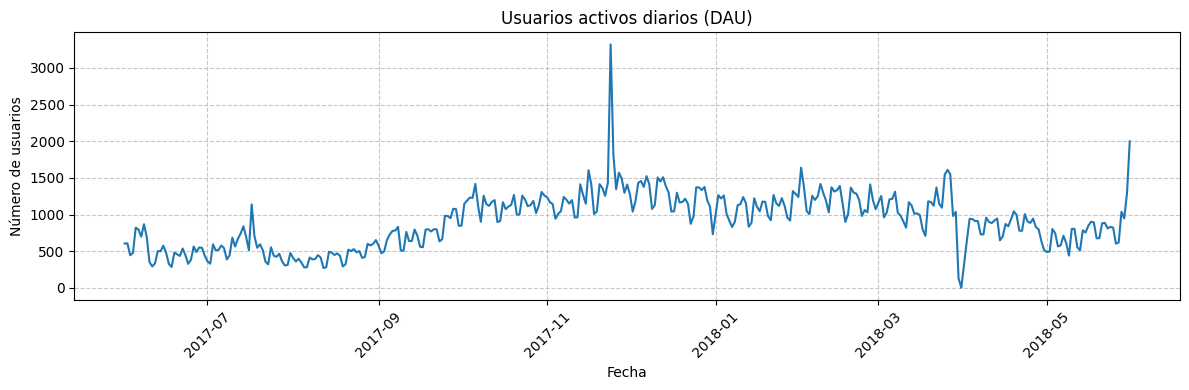

In [13]:
# Usuarios activos diarios (DAU)
dau = (
    visits.groupby('session_date')
    .agg({'uid': 'nunique'})
    .reset_index()
)
dau.columns = ['session_date', 'n_users']
print("\n=== Usuarios activos diarios (DAU) ===")
print(dau.head())

plt.figure(figsize=(12, 4))
plt.plot(dau['session_date'], dau['n_users'])
plt.title('Usuarios activos diarios (DAU)')
plt.xlabel('Fecha')
plt.ylabel('Número de usuarios')
plt.xticks(rotation=45)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### Usuarios activos semanales (WAU)

=== Usuarios activos semanales (WAU) ===

            session_week  n_users
0  2017-05-29/2017-06-04     2021
1  2017-06-05/2017-06-11     4129
2  2017-06-12/2017-06-18     2812
3  2017-06-19/2017-06-25     2878
4  2017-06-26/2017-07-02     3064


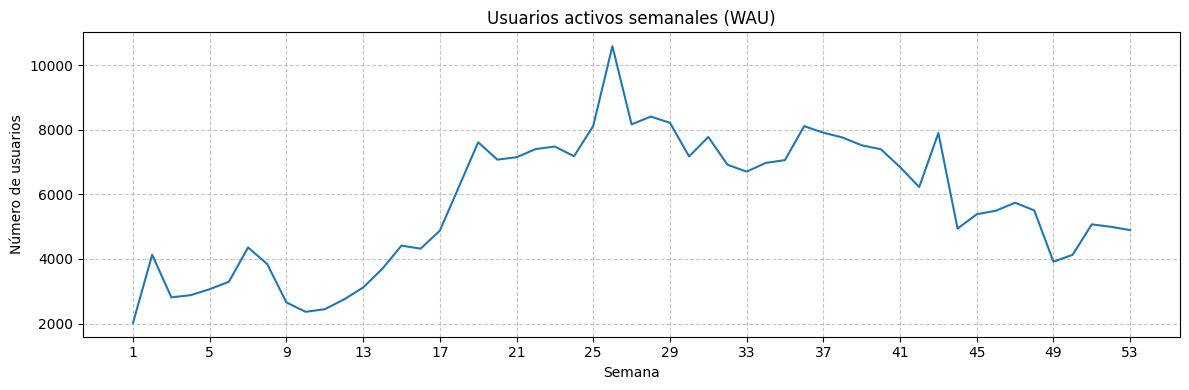

In [14]:
# Usuarios activos semanales (WAU)
wau = (
    visits.groupby('session_week')
    .agg({'uid': 'nunique'})
    .reset_index()
)
wau.columns = ['session_week', 'n_users']
print("=== Usuarios activos semanales (WAU) ===\n")
print(wau.head())

# Crear un índice de semana para el gráfico
wau['week_number'] = range(1, len(wau) + 1)

plt.figure(figsize=(12, 4))
plt.plot(wau['week_number'], wau['n_users'])
plt.title('Usuarios activos semanales (WAU)')
plt.xlabel('Semana')
plt.ylabel('Número de usuarios')
plt.xticks(wau['week_number'][::4])
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### Usuarios activos mensuales (MAU)

=== Usuarios activos mensuales (MAU) ===

  session_month  n_users
0    2017-06-01    13259
1    2017-07-01    14183
2    2017-08-01    11631
3    2017-09-01    18975
4    2017-10-01    29692


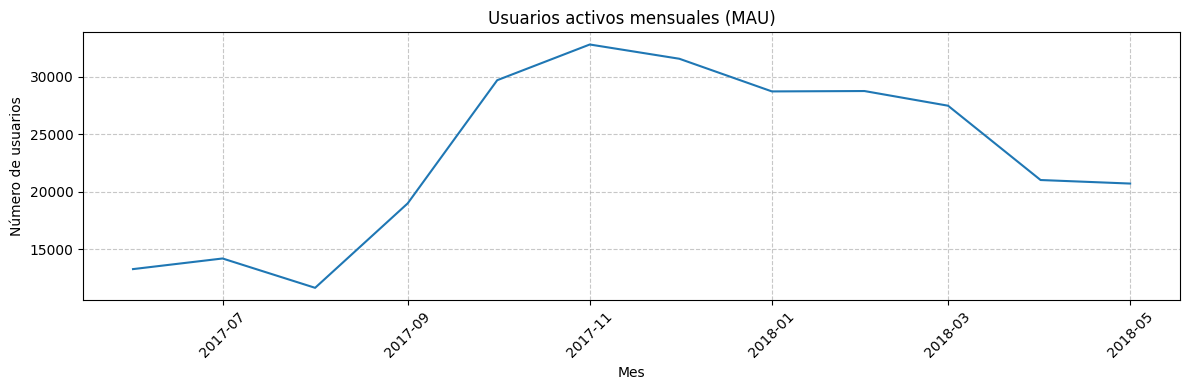

In [15]:
# Usuarios activos mensuales (MAU)
mau = (
    visits.groupby('session_month')
    .agg({'uid': 'nunique'})
    .reset_index()
)
mau.columns = ['session_month', 'n_users']

print("=== Usuarios activos mensuales (MAU) ===\n")
print(mau.head())

plt.figure(figsize=(12, 4))
plt.plot(mau['session_month'], mau['n_users'])
plt.title('Usuarios activos mensuales (MAU)')
plt.xlabel('Mes')
plt.ylabel('Número de usuarios')
plt.xticks(rotation=45)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### 2.1.2 -> ¿Cuántas sesiones hay por día?

=== Número de sesiones por día ===

  session_date  n_sessions
0   2017-06-01         664
1   2017-06-02         658
2   2017-06-03         477
3   2017-06-04         510
4   2017-06-05         893


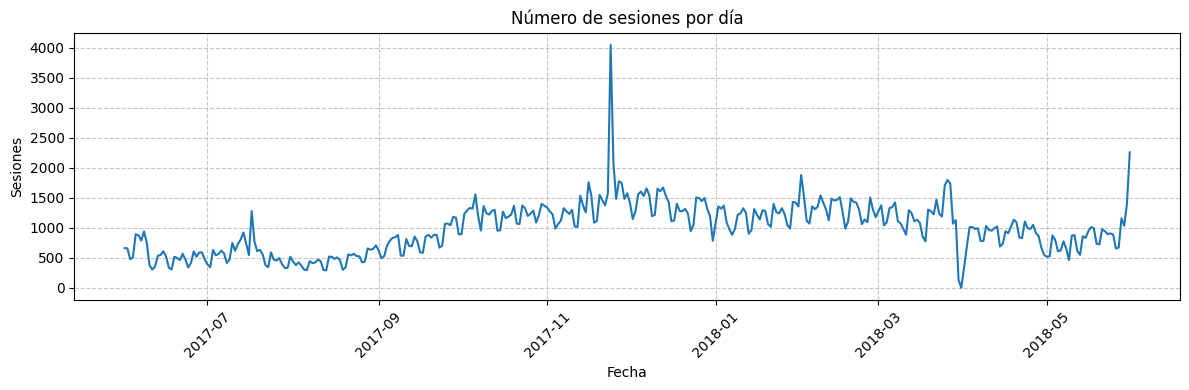

In [16]:
sessions_per_day = (
    visits.groupby('session_date')
    .size()
    .reset_index(name='n_sessions')
)
print("=== Número de sesiones por día ===\n")
print(sessions_per_day.head())

plt.figure(figsize=(12, 4))
plt.plot(sessions_per_day['session_date'], sessions_per_day['n_sessions'])
plt.title('Número de sesiones por día')
plt.xlabel('Fecha')
plt.ylabel('Sesiones')
plt.xticks(rotation=45)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### 2.1.3 -> ¿Cuál es la duración de cada sesión?

In [17]:
# Estadísticas generales de duración de sesión (en minutos)
print("=== visits stadistics ===\n")
print(visits['session_duration_min'].describe())


=== visits stadistics ===

count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration_min, dtype: float64


=== Duración promedio de sesión por día (minutos) ===

  session_date  session_duration_min
0   2017-06-01             11.105346
1   2017-06-02             10.330674
2   2017-06-03             10.115968
3   2017-06-04              9.238497
4   2017-06-05             10.407503


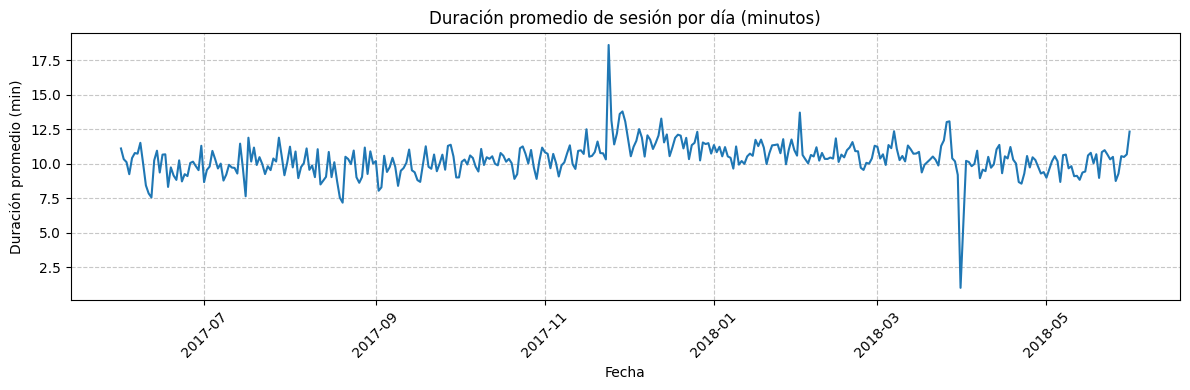

In [18]:
# Duración promedio de sesión por día
avg_session_duration_per_day = (
    visits.groupby('session_date')['session_duration_min']
    .mean()
    .reset_index()
)
print("=== Duración promedio de sesión por día (minutos) ===\n")
print(avg_session_duration_per_day.head())

plt.figure(figsize=(12, 4))
plt.plot(
    avg_session_duration_per_day['session_date'],
    avg_session_duration_per_day['session_duration_min']
)
plt.title('Duración promedio de sesión por día (minutos)')
plt.xlabel('Fecha')
plt.ylabel('Duración promedio (min)')
plt.xticks(rotation=45)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### 2.1.4 -> ¿Con qué frecuencia los usuarios regresan?

=== Distribución de días entre sesiones ===

count    131231.00
mean         27.68
std          49.69
min           0.00
25%           0.00
50%           4.00
75%          31.00
max         362.00
Name: days_since_prev_session, dtype: float64


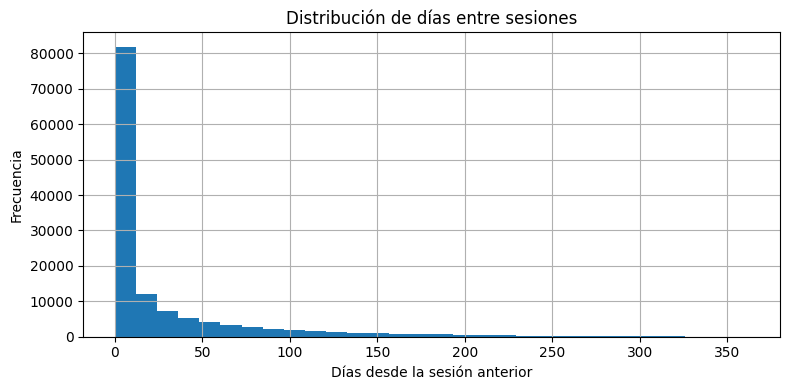

In [19]:
# Ordenar por usuario y timestamp
visits_sorted = visits.sort_values(['uid', 'start_ts']).copy()

# Timestamp de la sesión anterior de cada usuario
visits_sorted['prev_session_ts'] = (
    visits_sorted.groupby('uid')['start_ts'].shift()
)

# Días desde la sesión anterior
visits_sorted['days_since_prev_session'] = (
    visits_sorted['start_ts'] - visits_sorted['prev_session_ts']
).dt.days

# Quitamos los NaN (primera sesión de cada usuario)
return_intervals = visits_sorted['days_since_prev_session'].dropna()

print("=== Distribución de días entre sesiones ===\n")
print(return_intervals.describe().round(2))

plt.figure(figsize=(8, 4))
return_intervals.hist(bins=30)
plt.title('Distribución de días entre sesiones')
plt.xlabel('Días desde la sesión anterior')
plt.ylabel('Frecuencia')
plt.tight_layout()


### 2.2.1  -> ¿Cuándo empieza la gente a comprar?

In [20]:
# Fecha por día y por mes de cada pedido
orders['order_date'] = orders['buy_ts'].dt.date
orders['order_month'] = orders['buy_ts'].astype('datetime64[M]')

In [21]:
# Primera visita por usuario
first_visits = (
    visits.groupby('uid')
    .agg({'start_ts': 'min'})
    .reset_index()
)
first_visits.columns = ['uid', 'first_visit_ts']

# Primera compra por usuario
first_orders = (
    orders.groupby('uid')
    .agg({'buy_ts': 'min'})
    .reset_index()
)
first_orders.columns = ['uid', 'first_order_ts']

# Unimos en una tabla de usuarios
users = first_visits.merge(first_orders, on='uid', how='left')

# Días hasta la conversión (solo donde sí hay compra)
users['conversion_days'] = (
    users['first_order_ts'] - users['first_visit_ts']
).dt.days

# Filtramos valores raros (conversiones negativas o sin compra)
users_converted = users[users['conversion_days'] >= 0]

print("\n=== Estadísticas de días desde la primera visita hasta la primera compra ===")
users_converted['conversion_days'].describe()



=== Estadísticas de días desde la primera visita hasta la primera compra ===


count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: conversion_days, dtype: float64


=== Días desde la primera visita hasta la primera compra ===
   conversion_days  n_users
0              0.0    26363
1              1.0     1011
2              2.0      563
3              3.0      434
4              4.0      324
5              5.0      270
6              6.0      260
7              7.0      218
8              8.0      189
9              9.0      140


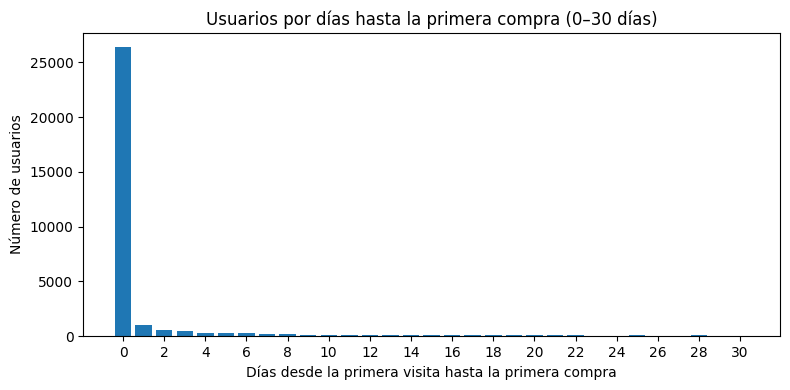

In [22]:
conversion_counts = (
    users_converted['conversion_days']
    .value_counts()
    .sort_index()
    .reset_index()
)
conversion_counts.columns = ['conversion_days', 'n_users']

print("\n=== Días desde la primera visita hasta la primera compra ===")
print(conversion_counts.head(10))

# Nos enfocamos en conversiones de 0 a 30 días
conv_30 = conversion_counts[conversion_counts['conversion_days'] <= 30]

plt.figure(figsize=(8, 4))
plt.bar(conv_30['conversion_days'], conv_30['n_users'])
plt.title('Usuarios por días hasta la primera compra (0–30 días)')
plt.xlabel('Días desde la primera visita hasta la primera compra')
plt.ylabel('Número de usuarios')

# Etiquetar cada 2 días para que no se sature
plt.xticks(range(0, 31, 2))

plt.tight_layout()


### 2.2.2 -> ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [23]:
# Número de pedidos por día
orders_per_day = (
    orders.groupby('order_date')
    .size()
    .reset_index(name='n_orders')
)
print("\n=== pedidos por día ===")
orders_per_day.head()



=== pedidos por día ===


,order_date,n_orders
0,2017-06-01,96
1,2017-06-02,111
2,2017-06-03,67
3,2017-06-04,66
4,2017-06-05,161


In [24]:
# Número de pedidos por mes
orders_per_month = (
    orders.groupby('order_month')
    .size()
    .reset_index(name='n_orders')
)
print("\n=== pedidos por mes ===")
orders_per_month.head()



=== pedidos por mes ===


,order_month,n_orders
0,2017-06-01,2354
1,2017-07-01,2363
2,2017-08-01,1807
3,2017-09-01,3387
4,2017-10-01,5679


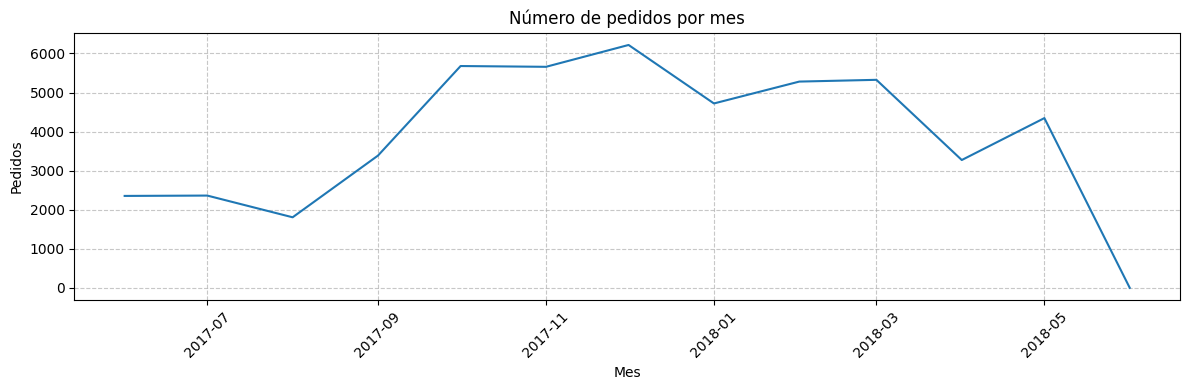

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(orders_per_month['order_month'], orders_per_month['n_orders'])
plt.title('Número de pedidos por mes')
plt.xlabel('Mes')
plt.ylabel('Pedidos')
plt.xticks(rotation=45)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### 2.2.3 -> ¿Cuál es el tamaño promedio de compra?

In [26]:
# Tamaño promedio de compra general
avg_order_value = orders['revenue'].mean()
print("=== Tamaño promedio de compra general ===")
print(avg_order_value.round(5))


=== Tamaño promedio de compra general ===
4.99965


=== Tamaño promedio de compra por mes ===

  order_month  avg_revenue
0  2017-06-01     4.060106
1  2017-07-01     5.306589
2  2017-08-01     4.847139
3  2017-09-01     5.416448
4  2017-10-01     4.928280


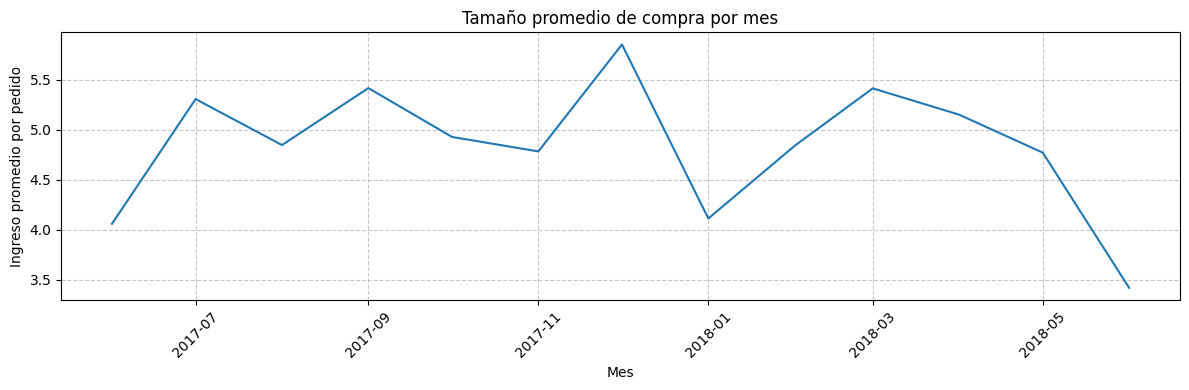

In [27]:
# Por mes
avg_order_value_per_month = (
    orders.groupby('order_month')['revenue']
    .mean()
    .reset_index()
)
avg_order_value_per_month.columns = ['order_month', 'avg_revenue']

print("=== Tamaño promedio de compra por mes ===\n")
print(avg_order_value_per_month.head())

plt.figure(figsize=(12, 4))
plt.plot(
    avg_order_value_per_month['order_month'],
    avg_order_value_per_month['avg_revenue']
)
plt.title('Tamaño promedio de compra por mes')
plt.xlabel('Mes')
plt.ylabel('Ingreso promedio por pedido')
plt.xticks(rotation=45)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### 2.2.4 -> ¿Cuánto dinero traen? (LTV por usuario)

In [28]:
# LTV por usuario (suma del revenue)
user_ltv = (
    orders.groupby('uid')['revenue']
    .sum()
    .reset_index()
)
user_ltv.columns = ['uid', 'ltv']

print("\n=== LTV ===")
print(user_ltv.head())
print("\n=== LTV stadistics ===")
user_ltv['ltv'].describe()



=== LTV ===
                    uid    ltv
0  10000837700716403746   2.20
1  10000997030965831953   1.83
2  10001199569370567060   1.00
3  10002243978166172255  17.41
4  10003351403065971701   6.72

=== LTV stadistics ===


count    36523.000000
mean         6.901328
std         88.128535
min          0.000000
25%          1.470000
50%          3.050000
75%          5.800000
max      11810.180000
Name: ltv, dtype: float64

### 2.3.1 -> ¿Cuánto dinero se gastó?

In [29]:
# Aseguramos formato de fecha y mes en costs
costs['dt'] = pd.to_datetime(costs['dt'])
costs['month'] = costs['dt'].astype('datetime64[M]')

# Gasto total
total_costs = costs['costs'].sum()
print(f'Gasto total en marketing: ${total_costs}')

# Gasto por fuente
costs_by_source = (
    costs.groupby('source_id')['costs']
    .sum()
    .reset_index()
)
print("\n=== costo por canal de marketing ===")
print(costs_by_source)

# Gasto por mes
costs_by_month = (
    costs.groupby('month')['costs']
    .sum()
    .reset_index()
)
print("\n=== costo por mes ===")
print(costs_by_month.head())


Gasto total en marketing: $329131.62

=== costo por canal de marketing ===
  source_id      costs
0         1   20833.27
1         2   42806.04
2         3  141321.63
3         4   61073.60
4         5   51757.10
5         9    5517.49
6        10    5822.49

=== costo por mes ===
       month     costs
0 2017-06-01  18015.00
1 2017-07-01  18240.59
2 2017-08-01  14790.54
3 2017-09-01  24368.91
4 2017-10-01  36322.88


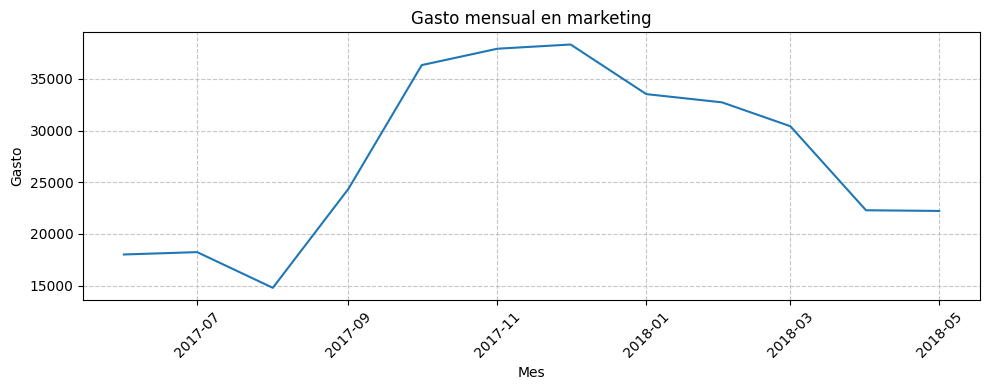

In [30]:
# Gasto total por mes
plt.figure(figsize=(10, 4))
plt.plot(costs_by_month['month'], costs_by_month['costs'])
plt.title('Gasto mensual en marketing')
plt.xlabel('Mes')
plt.ylabel('Gasto')
plt.xticks(rotation=45)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


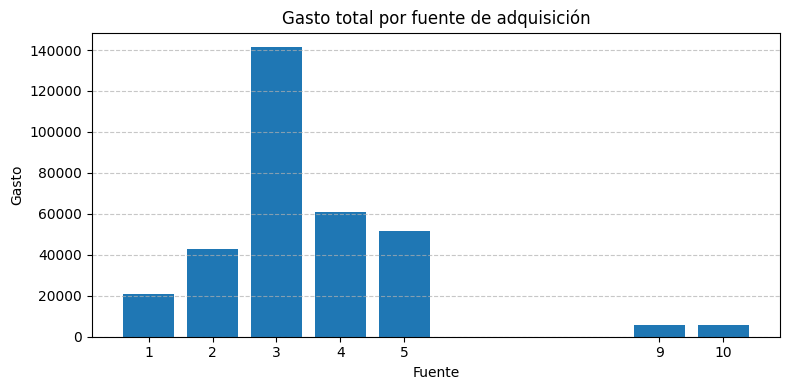

In [31]:
# Gasto por fuente (barra)
plt.figure(figsize=(8, 4))
plt.bar(costs_by_source['source_id'], costs_by_source['costs'])
plt.title('Gasto total por fuente de adquisición')
plt.xlabel('Fuente')
plt.ylabel('Gasto')
plt.xticks(costs_by_source['source_id'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


### 2.3.2 CAC: costo de adquisición de clientes por fuente

#### Primera fuente de cada usuario

In [32]:
# Ordenamos visitas por usuario y tiempo
visits_sorted = visits.sort_values(['uid', 'start_ts']).copy()

# Primera visita de cada usuario (con su fuente y dispositivo)
first_touch = visits_sorted.drop_duplicates('uid', keep='first')[
    ['uid', 'source_id', 'device']
]
first_touch.columns = ['uid', 'first_source_id', 'first_device']

first_touch.head()


,uid,first_source_id,first_device
161613,10000171586432207426,3,desktop
213852,10000344846682484395,3,desktop
86970,1000036778515242839,3,desktop
175418,10000460875579931334,4,touch
198336,10000558740593440652,4,desktop


#### Clientes (usuarios que sí compraron) por fuente

In [33]:
# Usuarios que hicieron al menos un pedido
buyers = orders['uid'].unique()

# Primera fuente solo para los que sí compraron
buyers_first_touch = first_touch[first_touch['uid'].isin(buyers)].copy()

buyers_per_source = (
    buyers_first_touch.groupby('first_source_id')['uid']
    .nunique()
    .reset_index()
)
buyers_per_source.columns = ['source_id', 'n_buyers']

buyers_per_source


,source_id,n_buyers
0,1,2899
1,2,3506
2,3,10473
3,4,10296
4,5,6931
5,6,0
6,7,1
7,9,1088
8,10,1329


#### CAC por fuente


=== CAC por fuente de adquisición ===
   source_id      costs  n_buyers        cac
0          1   20833.27      2899   7.186364
1          2   42806.04      3506  12.209367
2          3  141321.63     10473  13.493901
3          4   61073.60     10296   5.931779
4          5   51757.10      6931   7.467479
5          9    5517.49      1088   5.071222
6         10    5822.49      1329   4.381106



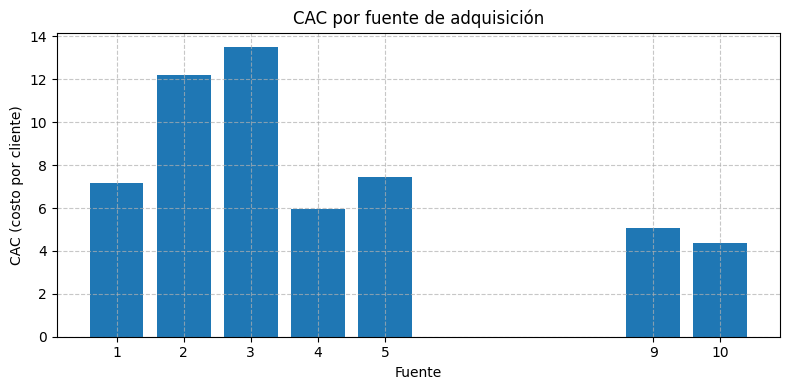

In [34]:
cac = costs_by_source.merge(buyers_per_source, on='source_id', how='left')

cac['cac'] = cac['costs'] / cac['n_buyers']

print("\n=== CAC por fuente de adquisición ===")
print(f'{cac}\n')

plt.figure(figsize=(8, 4))
plt.bar(cac['source_id'], cac['cac'])
plt.title('CAC por fuente de adquisición')
plt.xlabel('Fuente')
plt.ylabel('CAC (costo por cliente)')
plt.xticks(costs_by_source['source_id'])
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### 2.3.3 ROMI: rentabilidad de las inversiones por fuente

#### ingresos por fuente

In [35]:
# Pedidos con información de fuente y dispositivo del usuario
orders_with_source = orders.merge(first_touch, on='uid', how='left')

revenue_by_source = (
    orders_with_source.groupby('first_source_id')['revenue']
    .sum()
    .reset_index()
)
revenue_by_source.columns = ['source_id', 'revenue']
print("=== ingresos por fuente ===\n")
revenue_by_source


=== ingresos por fuente ===



,source_id,revenue
0,1,31090.55
1,2,46923.61
2,3,54511.24
3,4,56696.83
4,5,52624.02
5,6,0.00
6,7,1.22
7,9,5759.40
8,10,4450.33


#### ROMI por fuente


=== ROMI por fuente ===
   source_id      costs   revenue      romi
0          1   20833.27  31090.55  0.492351
1          2   42806.04  46923.61  0.096191
2          3  141321.63  54511.24 -0.614275
3          4   61073.60  56696.83 -0.071664
4          5   51757.10  52624.02  0.016750
5          9    5517.49   5759.40  0.043844
6         10    5822.49   4450.33 -0.235665


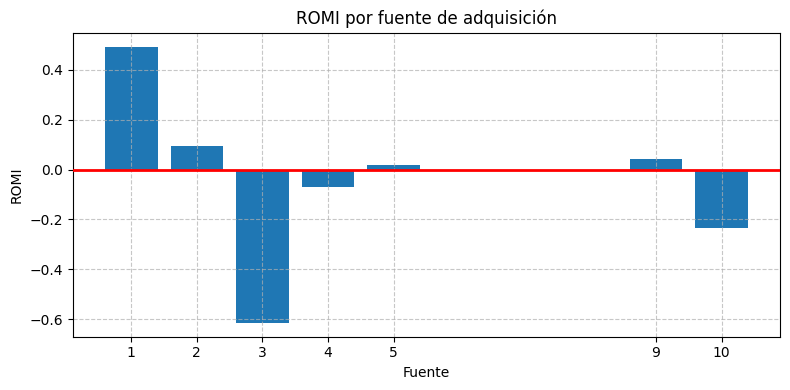

In [36]:
romi = costs_by_source.merge(revenue_by_source, on='source_id', how='left')

romi['romi'] = (romi['revenue'] - romi['costs']) / romi['costs']

print("\n=== ROMI por fuente ===")
print(romi)

plt.figure(figsize=(8, 4))
plt.bar(romi['source_id'], romi['romi'])
plt.title('ROMI por fuente de adquisición')
plt.xlabel('Fuente')
plt.ylabel('ROMI')
plt.xticks(costs_by_source['source_id'])
plt.axhline(y=0, color='red', linewidth=2, zorder=3)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### Ingresos por dispositivo

=== Ingresos totales por dispositivo ===

  first_device    revenue
0      desktop  211329.77
1        touch   40727.43


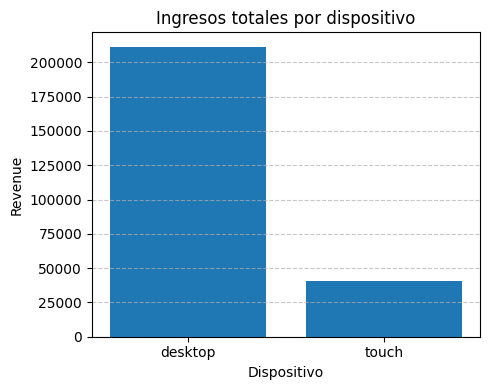

In [37]:
revenue_by_device = (
    orders_with_source.groupby('first_device')['revenue']
    .sum()
    .reset_index()
)
print("=== Ingresos totales por dispositivo ===\n")
print(revenue_by_device)

plt.figure(figsize=(5, 4))
plt.bar(revenue_by_device['first_device'], revenue_by_device['revenue'])
plt.title('Ingresos totales por dispositivo')
plt.xlabel('Dispositivo')
plt.ylabel('Revenue')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


### Ingresos mensuales por fuente

<Figure size 1500x800 with 0 Axes>

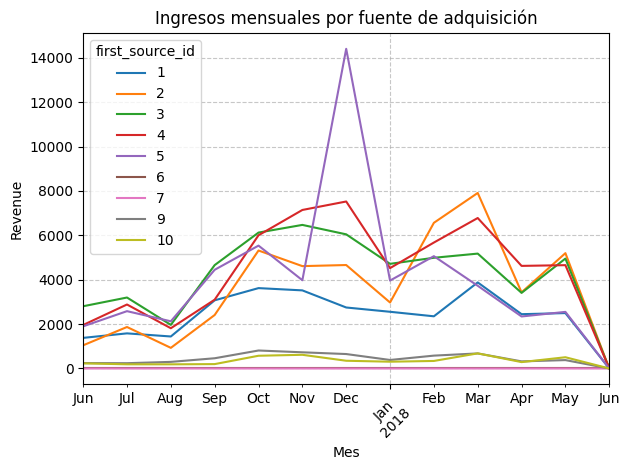

In [38]:
orders_with_source['order_month'] = orders_with_source['buy_ts'].astype('datetime64[M]')

rev_month_source = (
    orders_with_source
    .groupby(['order_month', 'first_source_id'])['revenue']
    .sum()
    .reset_index()
)

rev_pivot = rev_month_source.pivot(
    index='order_month',
    columns='first_source_id',
    values='revenue'
)

plt.figure(figsize=(15, 8))
rev_pivot.plot()
plt.title('Ingresos mensuales por fuente de adquisición')
plt.xlabel('Mes')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True, axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()


### Conclusiones de marketing

- El gasto total en marketing se reparte entre varias fuentes de adquisición, pero no todas aprovechan el presupuesto con la misma eficiencia. Algunas fuentes generan mucho tráfico y pedidos, mientras que otras absorben parte importante del presupuesto sin aportar ingresos proporcionales.

- Al comparar el CAC con el LTV por fuente, se observa que en las fuentes con mejor desempeño el **LTV promedio por cliente es claramente mayor que el CAC**, por lo que cada cliente adquirido deja una contribución positiva al negocio. En cambio, en las fuentes menos eficientes el **CAC se acerca o incluso supera al LTV**, lo que indica que **la inversión en esos canales no se recupera por completo.**

- El análisis del ROMI confirma esta diferencia: existen fuentes con **ROMI positivo**, donde cada dólar invertido regresa con beneficio adicional, y otras con **ROMI cercano a cero o negativo**, donde el retorno es bajo o inexistente. Estas últimas funcionan más como gasto que como inversión.

- En términos de comportamiento del usuario, la mayoría de las conversiones ocurre relativamente pronto después de la primera visita. Esto sugiere que **las campañas de remarketing deben concentrarse en las primeras etapas del ciclo de vida del usuario**, cuando la probabilidad de compra es más alta.

**Recomendaciones para el equipo de marketing**

1. **Mantener e incrementar la inversión** en las fuentes con ROMI positivo y CAC por debajo del LTV, ya que son las que traen clientes realmente rentables.
2. **Reducir o pausar la inversión** en las fuentes con ROMI negativo y revisar su segmentación, mensajes y landing pages antes de volver a asignarles presupuesto.
3. **Priorizar los canales y dispositivos** que muestren mejor relación entre LTV y CAC, incluso si su volumen es menor, porque aportan más valor por cliente.
4. Diseñar **flujos de remarketing enfocados en los primeros días** tras el registro/primera visita (emails, notificaciones, anuncios), aprovechando la ventana donde se concentra la mayor parte de las conversiones.


### Conclusión adicional sobre el comportamiento de los usuarios y la inversión

- El **tráfico y el número de sesiones por día** muestran una **tendencia creciente** desde mediados de 2017 hasta finales de año, con picos claros en noviembre-diciembre. A partir de 2018 el volumen de sesiones y pedidos se mantiene relativamente alto aun cuando el **gasto en marketing empieza a reducirse**, lo que sugiere que la marca ya tiene **cierto reconocimiento** y no depende tanto de incrementar continuamente el presupuesto.

- La **duración promedio de las sesiones** se mantiene bastante estable (alrededor de 9-11 minutos), con algunos picos y caídas puntuales. Esto indica que, aunque crece el número de usuarios, el nivel de **“engagement”** de quienes usan la plataforma **no cambia de forma drástica**.

- El **intervalo entre sesiones** está muy sesgado: muchos usuarios regresan el mismo día o dentro de los primeros 4 días, pero existe una cola larga de usuarios que vuelven semanas o meses después. Esto refleja una base de usuarios que combina **clientes frecuentes** con otros más **ocasionales**.

- La **conversión a la primera compra es muy rápida**: la mayoría de los clientes compra el **mismo día de la primera visita** y una parte importante lo hace en los **primeros días**. Esto confirma que la decisión de compra es de **baja fricción**; por tanto, las campañas más efectivas serán las que impacten al usuario en **esa primera visita o durante la primera semana**.

- Al cruzar pedidos, tamaño promedio de la compra y gasto mensual, se observa que el aumento del presupuesto de marketing en la segunda mitad de 2017 sí se traduce en más pedidos e ingresos, pero posteriormente la empresa consigue mantener buenos niveles de ventas con **menos gasto**. Esto abre espacio para **optimizar la inversión**: focalizar el presupuesto en las **fuentes con mejor ROMI** y apoyarse más en la **retención** y en los **canales orgánicos** a medida que el producto madura.
